Mean-centered data:
 [[ 0.46  0.16]
 [-1.54 -1.54]
 [ 0.16  0.66]
 [-0.14 -0.04]
 [ 1.06  0.76]]
Covariance Matrix:
 [[0.938  0.8405]
 [0.8405 0.853 ]]
[1.73707382 0.05392618] [[ 0.72474155 -0.68902082]
 [ 0.68902082  0.72474155]]
Principal Component (PC1):
 [0.72474155 0.68902082]
Projected Data:
 [ 0.44362444 -2.17719404  0.57071239 -0.12902465  1.29188186]


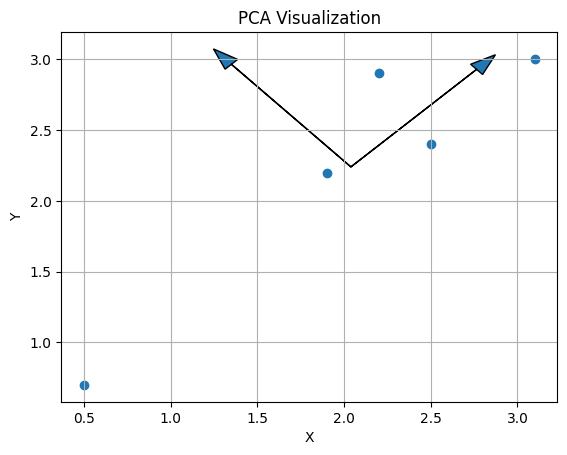

In [ ]:
#Example:1

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
X = np.array([[2.5, 2.4],
[0.5, 0.7],
[2.2, 2.9],
[1.9, 2.2],
[3.1, 3.0]])
X_meaned = X - np.mean(X, axis=0)
print("Mean-centered data:\n", X_meaned)
cov_matrix = np.cov(X_meaned.T)
print("Covariance Matrix:\n", cov_matrix)
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)
print(eigen_values, eigen_vectors)
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvectors = eigen_vectors[:, sorted_index]
pc1 = sorted_eigenvectors[:, 0]
print("Principal Component (PC1):\n", pc1)
X_reduced = np.dot(X_meaned, pc1)
print("Projected Data:\n", X_reduced)
plt.figure()
plt.scatter(X[:,0], X[:,1])
# Plot principal components
mean = np.mean(X, axis=0)
for i in range(2):
 vec = sorted_eigenvectors[:, i]
 plt.arrow(mean[0], mean[1], vec[0], vec[1], head_width=0.1)
plt.title("PCA Visualization")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

Dataset shape: (70000, 784)
Components: 100, MSE: 0.005723196798245504
Components: 50, MSE: 0.011748092185972992
Components: 10, MSE: 0.03437132972324286


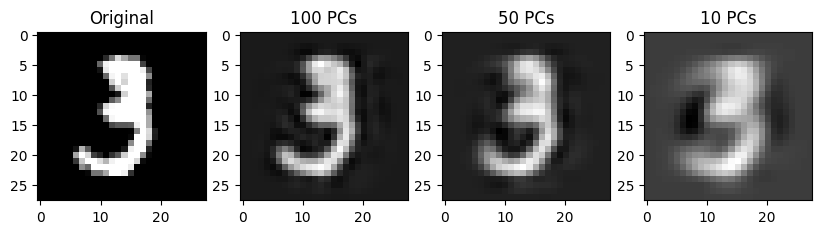

In [ ]:
#Example:2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target
print("Dataset shape:", X.shape)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
components_list = [100, 50, 10]
reconstructed_images = {}
mse_values = []
for n in components_list:
 pca = PCA(n_components=n)
# Reduce dimensions
 X_reduced = pca.fit_transform(X_scaled)
# Reconstruct data
 X_reconstructed =pca.inverse_transform(X_reduced)
 # Store results
 reconstructed_images[n] = X_reconstructed
 # Compute error
 mse = mean_squared_error(X_scaled,X_reconstructed)
 mse_values.append(mse)
 print(f"Components: {n}, MSE: {mse}")

def plot_images(original, reconstructed_dict, index=0):
    plt.figure(figsize=(10, 4))
    # Original image
    plt.subplot(1, len(reconstructed_dict)+1, 1)
    plt.imshow(original[index].reshape(28, 28), cmap='gray')
    plt.title("Original")
    # Reconstructed images
    i = 2
    for n, data in reconstructed_dict.items():
        plt.subplot(1, len(reconstructed_dict)+1,i)
        plt.imshow(data[index].reshape(28, 28), cmap='gray')
        plt.title(f"{n} PCs")
        i += 1
    plt.show()
plot_images(X_scaled, reconstructed_images, index=10)

Explained variance ratio of each principal component: [0.72962445 0.22850762 0.03668922 0.00517871]


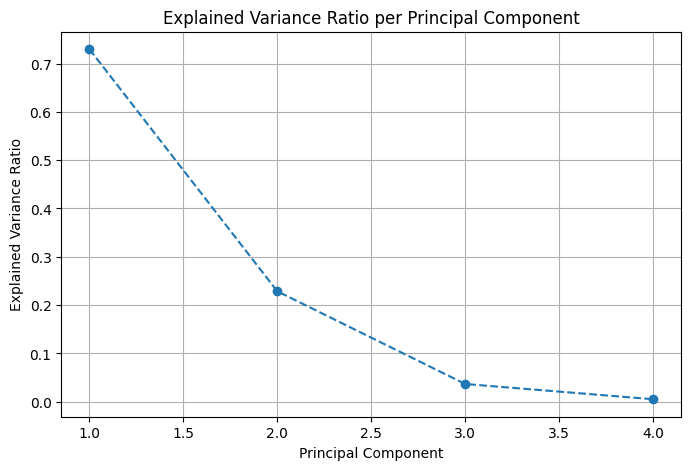

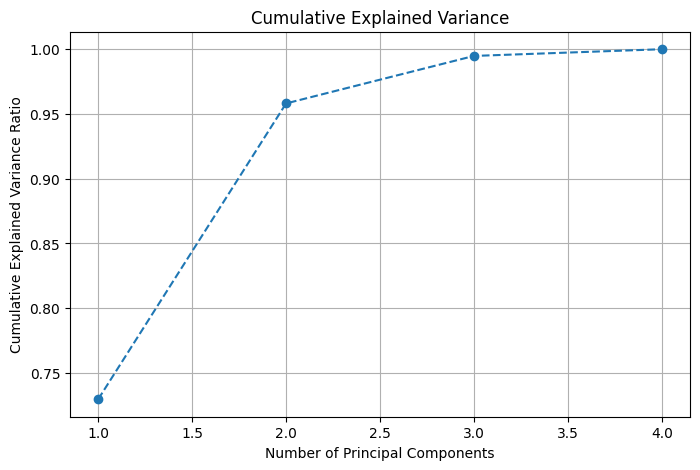

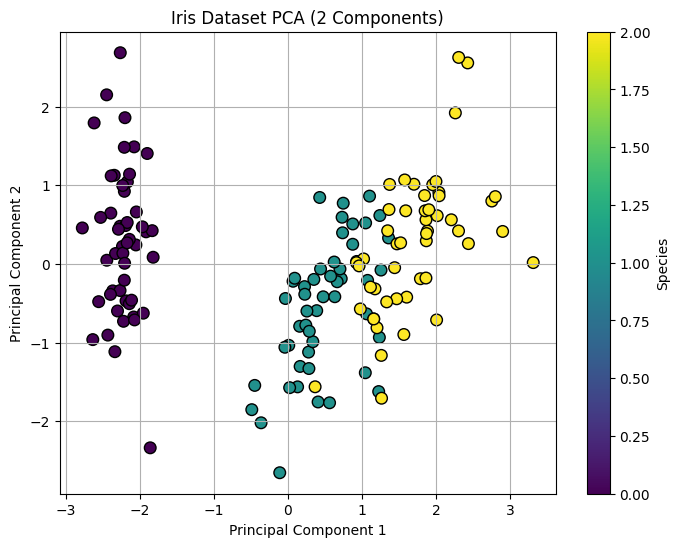

In [ ]:
#Excercise:1

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Analyze explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio of each principal component:", explained_variance_ratio)

# Plot the explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid()
plt.show()

# Plot cumulative explained variance
cumulative_explained_variance = explained_variance_ratio.cumsum()
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid()
plt.show()

# You can also visualize the data in 2D using the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=70)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Iris Dataset PCA (2 Components)')
plt.colorbar(label='Species')
plt.grid()
plt.show()

Player             0
COUNTRY            0
TEAM               0
AGE                0
CAPTAINCY EXP      0
Paying_Role        0
Mat                0
Inns              57
Runs              57
BF                57
HS                57
Avg               56
SR                57
NO                57
4s                57
6s                57
0s                58
50s               58
100s              58
TMat              64
TInns            102
TRuns            102
TBF              102
THS              102
TAvg             102
TSR              102
TNO              102
T4s              102
T6s              102
T0s              102
T50s             102
T100s            102
B_Inns            67
B_Balls           68
B_Runs            67
B_Maidens         68
B_Wkts            67
B_Avg             67
B_Econ            67
B_SR              67
B_4w              67
B_5w              67
B_TInns          104
B_TBalls         104
B_TRuns          104
B_TMaidens       104
B_TWkts          104
B_TAvg       

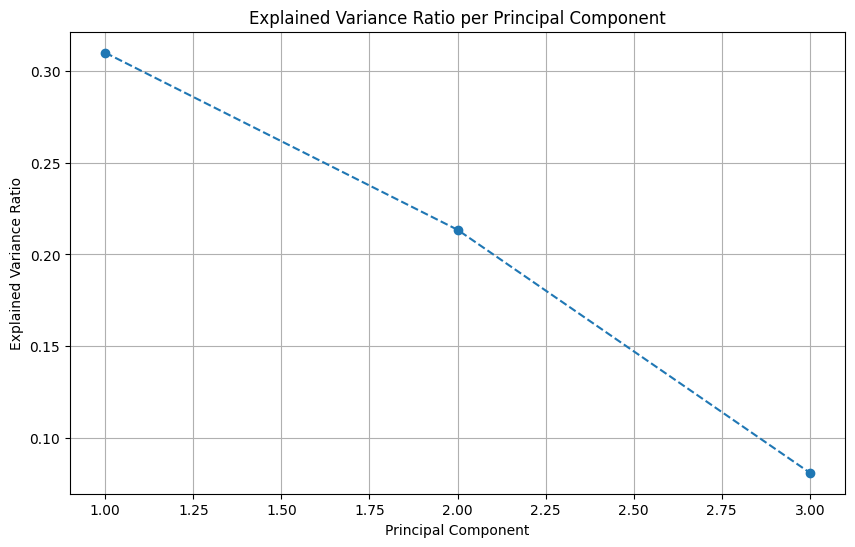

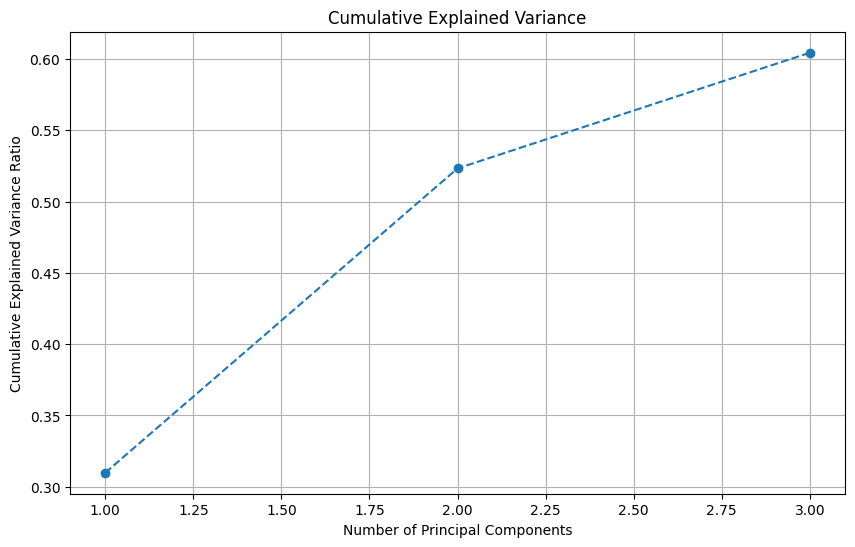

Principal Component Loadings:
          AGE  CAPTAINCY EXP       Mat      Inns      Runs        BF  \
PC1  0.100877       0.178396  0.162421  0.208842  0.232794  0.230118   
PC2  0.147441       0.048086  0.175145  0.083370  0.043600  0.040661   
PC3  0.072686       0.036624  0.245485  0.230851  0.185171  0.193790   

           HS       Avg        SR        NO  ...   B_TInns  B_TBalls  \
PC1  0.180336  0.158643  0.043231  0.100165  ... -0.055610 -0.061445   
PC2  0.027867  0.000526  0.017513  0.122910  ...  0.268369  0.269211   
PC3  0.152069  0.064406 -0.000514  0.181801  ... -0.115098 -0.103342   

      B_TRuns  B_TMaidens   B_TWkts    B_TAvg   B_TEcon     B_TSR     B_T4w  \
PC1 -0.061990   -0.049457 -0.063752 -0.094806 -0.011212 -0.091459 -0.052273   
PC2  0.264607    0.206187  0.261390  0.162248 -0.014843  0.174523  0.203978   
PC3 -0.108359   -0.049124 -0.114868  0.017618  0.032544  0.012338 -0.095401   

        B_T5w  
PC1 -0.036268  
PC2  0.151568  
PC3 -0.083002  

[3 rows x 

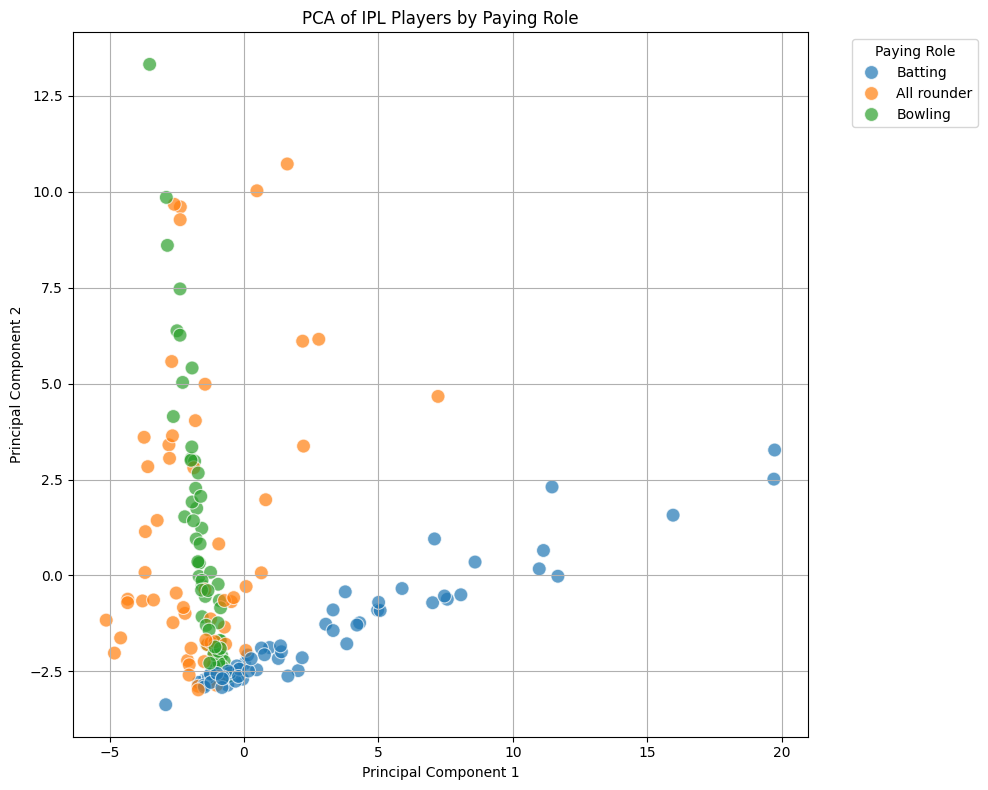

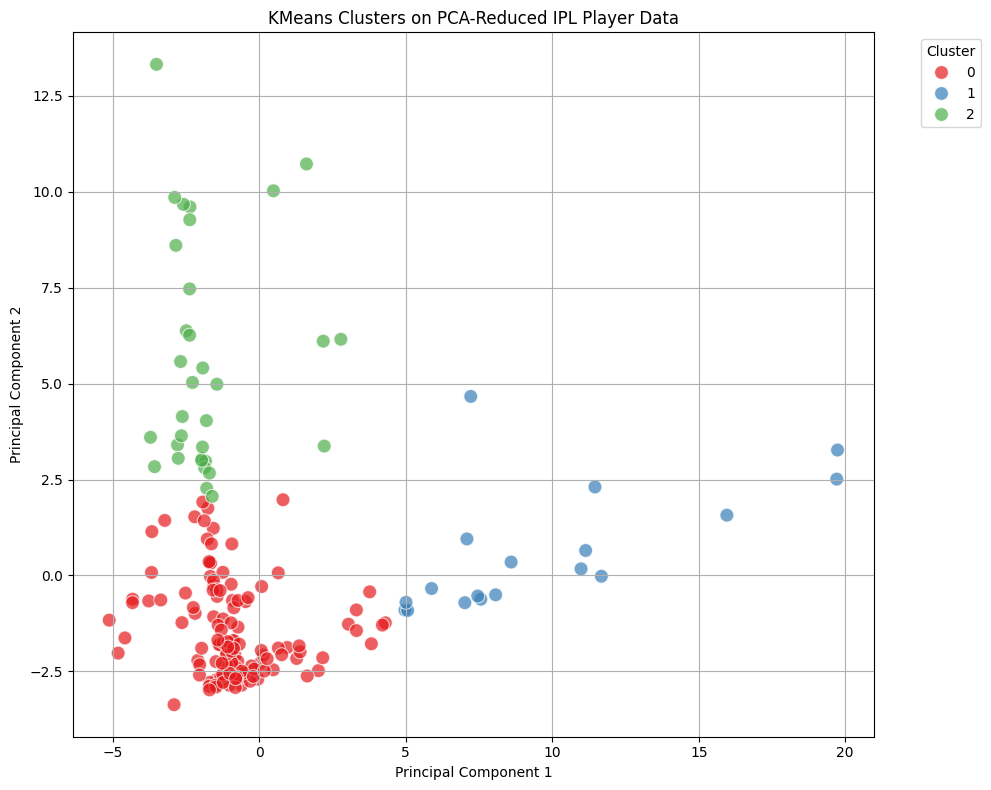


Cluster vs Paying Role:
Paying_Role  All rounder  Batting  Bowling
Cluster                                   
0                     41       48       42
1                      1       17        0
2                     17        0       16


In [2]:
# Exercise 2: PCA on IPL Player Stats

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df_cricket = pd.read_csv('/content/IPL dataset final.csv')

# Optional checks
print(df_cricket.isnull().sum())

# Convert important columns to numeric
numeric_convert_cols = [
    'Avg', 'B_Avg', 'B_Econ', 'B_SR',
    'B_TAvg', 'B_TEcon', 'B_TSR'
]

for col in numeric_convert_cols:
    if col in df_cricket.columns:
        df_cricket[col] = pd.to_numeric(df_cricket[col], errors='coerce')

# Identify numerical columns
numerical_cols = df_cricket.select_dtypes(include=np.number).columns.tolist()

# Exclude non-relevant columns
exclude_cols = ['Player', 'COUNTRY', 'TEAM', 'Paying_Role', 'SOLD_PRICE']
numerical_features = [col for col in numerical_cols if col not in exclude_cols]

# Bowling-related columns to fill with 0
bowling_0_fill_cols = [
    'B_Inns', 'B_Balls', 'B_Runs', 'B_Maidens', 'B_Wkts', 'B_Avg', 'B_Econ', 'B_SR', 'B_4w', 'B_5w',
    'B_TInns', 'B_TBalls', 'B_TRuns', 'B_TMaidens', 'B_TWkts', 'B_TAvg', 'B_TEcon', 'B_TSR', 'B_T4w', 'B_T5w'
]

# Keep only existing columns
bowling_0_fill_cols = [col for col in bowling_0_fill_cols if col in numerical_features]

# Fill bowling-related missing values with 0
for col in bowling_0_fill_cols:
    df_cricket[col] = df_cricket[col].fillna(0)

# Fill remaining numerical missing values with median
remaining_numerical_features = [col for col in numerical_features if col not in bowling_0_fill_cols]

for col in remaining_numerical_features:
    if df_cricket[col].isnull().any():
        df_cricket[col] = df_cricket[col].fillna(df_cricket[col].median())

# Standardize features
scaler = StandardScaler()
df_cricket_scaled = pd.DataFrame(
    scaler.fit_transform(df_cricket[numerical_features]),
    columns=numerical_features
)

# Apply PCA with 3 components
pca = PCA(n_components=3)
df_cricket_pca = pca.fit_transform(df_cricket_scaled)

# Explained variance
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio of each principal component:")
print(explained_variance_ratio)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker='o',
    linestyle='--'
)
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

# Cumulative explained variance
cumulative_explained_variance = explained_variance_ratio.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cumulative_explained_variance) + 1),
    cumulative_explained_variance,
    marker='o',
    linestyle='--'
)
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

# PCA loadings
principal_components = pca.components_
pca_loadings = pd.DataFrame(
    principal_components,
    columns=df_cricket_scaled.columns,
    index=[f'PC{i+1}' for i in range(len(principal_components))]
)

print("Principal Component Loadings:")
print(pca_loadings)

print("\nTop 5 features contributing to PC1 (absolute values):")
print(pca_loadings.loc['PC1'].abs().sort_values(ascending=False).head(5))

print("\nTop 5 features contributing to PC2 (absolute values):")
print(pca_loadings.loc['PC2'].abs().sort_values(ascending=False).head(5))

print("\nTop 5 features contributing to PC3 (absolute values):")
print(pca_loadings.loc['PC3'].abs().sort_values(ascending=False).head(5))

# Create PCA visualization dataframe
df_pca_viz = pd.DataFrame(df_cricket_pca[:, 0:2], columns=['PC1', 'PC2'])
df_pca_viz['Paying_Role'] = df_cricket['Paying_Role']

print("\nFirst five rows of PCA visualization dataframe:")
print(df_pca_viz.head())

# Plot PCA by Paying Role
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Paying_Role',
    data=df_pca_viz,
    s=100,
    alpha=0.7
)
plt.title('PCA of IPL Players by Paying Role')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Paying Role', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# KMeans clustering on first 2 principal components
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_cricket_pca[:, :2])

df_pca_viz['Cluster'] = clusters

# Plot PCA clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    data=df_pca_viz,
    s=100,
    alpha=0.7
)
plt.title('KMeans Clusters on PCA-Reduced IPL Player Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: compare clusters with player roles
print("\nCluster vs Paying Role:")
print(pd.crosstab(df_pca_viz['Cluster'], df_pca_viz['Paying_Role']))